# 03 - Paper Count Check Plot

In this notebook, I plot the number of accepted papers in the paper sample.

This is a simple check: it helps check whether the conference year paper
counts look plausible before I build the citation graph.


## 1 - Setup

In [1]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

from pathlib import Path
import shutil
from matplotlib.patches import Patch


In [2]:
import sys
from pathlib import Path

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "project_setup.py").exists() and (candidate / "config" / "project_config.yaml").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError(
        "Could not find the repository root. Launch Jupyter from the repo root "
        "or set PYTHONPATH to the folder containing project_setup.py."
    )

import sys
from pathlib import Path

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "config" / "project_config.yaml").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from project_setup import setup_project

setup = setup_project()
project_folder = setup.project_folder
PROJECT = project_folder
repo = project_folder
config_path = setup.config_path
project_config = setup.project_config

run_mode = setup.run_mode
inputs_config = setup.inputs
outputs_config = setup.outputs
openalex_config = setup.openalex

allow_network = setup.allow_network
use_existing_data = setup.use_existing_data
overwrite_data = setup.overwrite_data
overwrite_artifacts = setup.overwrite_artifacts
openalex_sample_limit = setup.openalex_sample_limit
openalex_sample_include_work_ids = setup.openalex_sample_include_work_ids

step_2_data_dir = project_folder / "step_2_data"
step_2_artifacts_dir = project_folder / "step_2_artifacts"
prepared_dir = step_2_data_dir / "prepared"
images_dir = step_2_artifacts_dir / "figures"
report_figures_dir = project_folder / "report_latex" / "figures"
summary_tables_dir = step_2_artifacts_dir / "summary_tables"
dependency_tables_dir = step_2_artifacts_dir / "dependency_tables"
check_tables_dir = step_2_artifacts_dir / "check_tables"

images_dir.mkdir(parents=True, exist_ok=True)
report_figures_dir.mkdir(parents=True, exist_ok=True)
summary_tables_dir.mkdir(parents=True, exist_ok=True)
dependency_tables_dir.mkdir(parents=True, exist_ok=True)
check_tables_dir.mkdir(parents=True, exist_ok=True)

font_path = project_folder / "fonts" / "LinLibertine_R.ttf"
if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
    prop = font_manager.FontProperties(fname=font_path)
    font_family = prop.get_name()
else:
    font_family = "serif"

mpl.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": font_family,
    "text.usetex": True,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

print(project_folder)
print(f"Run mode: {run_mode}")


/Users/endersari/2026-02-citations-vs-pc-memberships
Run mode: fast


## 2 - Load Paper Counts

In [3]:
all_papers = pd.read_parquet(prepared_dir / "all_papers" / "all_papers_filtered.parquet")

counts = (
    all_papers
    .groupby(["conference", "conference_year"])
    .size()
    .reset_index(name="n_papers")
)

counts.to_csv(summary_tables_dir / "paper_counts_plot_data.csv", index=False)

display(counts.sort_values(["conference", "conference_year"]))


,conference,conference_year,n_papers
0,ICFP,2017,44
1,ICFP,2018,40
2,ICFP,2019,39
3,ICFP,2020,36
4,ICFP,2021,35
5,ICFP,2022,35
6,ICFP,2023,33
7,ICFP,2024,35
8,ICFP,2025,36
9,OOPSLA,2017,66


## 3 - Plot

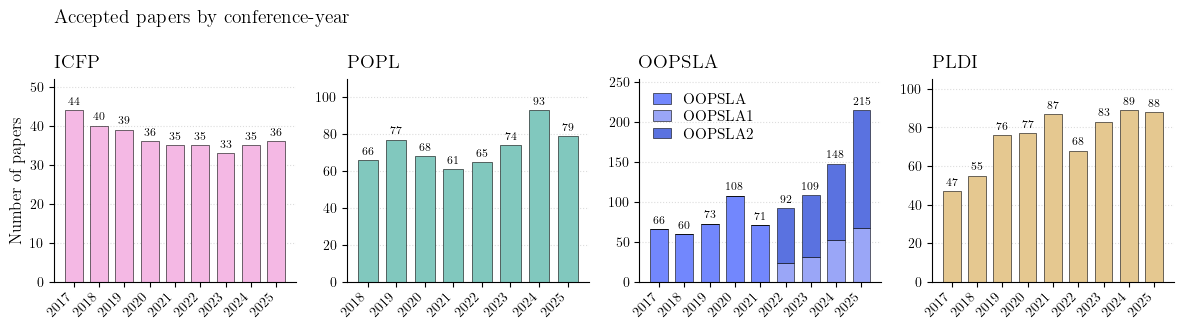

/Users/endersari/2026-02-citations-vs-pc-memberships/step_2_artifacts/figures/papers_per_conference_year.pdf
/Users/endersari/2026-02-citations-vs-pc-memberships/step_2_artifacts/figures/papers_per_conference_year.png
/Users/endersari/2026-02-citations-vs-pc-memberships/report_latex/figures/papers_per_conference_year.pdf


In [4]:
YEARS = list(range(2017, 2026))
COLORS = {
    "ICFP": "#f4b8e4",
    "POPL": "#81c8be",
    "OOPSLA": "#7287fd",
    "OOPSLA1": "#9aa6f7",
    "OOPSLA2": "#5a72e0",
    "PLDI": "#e5c890",
}


def count_for(conference, years):
    table = (
        counts[counts["conference"] == conference]
        .set_index("conference_year")["n_papers"]
    )
    return np.array([table.get(year, 0) for year in years])


def style_axis(ax, title, years):
    ax.set_title(title, loc="left", pad=8)
    ax.set_xticks(np.arange(len(years)))
    ax.set_xticklabels(years, rotation=45, ha="right")
    ax.grid(axis="y", color="#DDDDDD", linestyle=":", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def annotate(ax, x, values):
    ymax = max(values) if len(values) else 1
    for xi, value in zip(x, values):
        if value > 0:
            ax.text(
                xi,
                value + ymax * 0.02,
                str(int(value)),
                ha="center",
                va="bottom",
                fontsize=8,
            )


fig, axes = plt.subplots(1, 4, figsize=(12, 3.35), sharey=False)
bar_width = 0.70

# ICFP
ax = axes[0]
x = np.arange(len(YEARS))
values = count_for("ICFP", YEARS)
ax.bar(x, values, bar_width, color=COLORS["ICFP"], edgecolor="black", linewidth=0.4)
annotate(ax, x, values)
style_axis(ax, "ICFP", YEARS)
ax.set_ylabel("Number of papers")
ax.set_ylim(0, max(values) * 1.18)

# POPL
ax = axes[1]
popl_years = list(range(2018, 2026))
x = np.arange(len(popl_years))
values = count_for("POPL", popl_years)
ax.bar(x, values, bar_width, color=COLORS["POPL"], edgecolor="black", linewidth=0.4)
annotate(ax, x, values)
style_axis(ax, "POPL", popl_years)
ax.set_ylim(0, max(values) * 1.18)

# OOPSLA
ax = axes[2]
x = np.arange(len(YEARS))
oopsla = count_for("OOPSLA", YEARS)
oopsla1 = count_for("OOPSLA1", YEARS)
oopsla2 = count_for("OOPSLA2", YEARS)
total = oopsla + oopsla1 + oopsla2
ax.bar(x, oopsla, bar_width, color=COLORS["OOPSLA"], edgecolor="black", linewidth=0.4, label="OOPSLA")
ax.bar(x, oopsla1, bar_width, bottom=oopsla, color=COLORS["OOPSLA1"], edgecolor="black", linewidth=0.4, label="OOPSLA1")
ax.bar(x, oopsla2, bar_width, bottom=oopsla + oopsla1, color=COLORS["OOPSLA2"], edgecolor="black", linewidth=0.4, label="OOPSLA2")
annotate(ax, x, total)
style_axis(ax, "OOPSLA", YEARS)
ax.set_ylim(0, max(total) * 1.18)
ax.legend(frameon=False, loc="upper left", handlelength=1.2, labelspacing=0.25)

# PLDI
ax = axes[3]
x = np.arange(len(YEARS))
values = count_for("PLDI", YEARS)
ax.bar(x, values, bar_width, color=COLORS["PLDI"], edgecolor="black", linewidth=0.4)
annotate(ax, x, values)
style_axis(ax, "PLDI", YEARS)
ax.set_ylim(0, max(values) * 1.18)

fig.tight_layout(w_pad=1.2, rect=[0, 0, 1, 0.90])
title_x = axes[0].get_position().x0
fig.suptitle(
    "Accepted papers by conference-year",
    x=title_x,
    y=0.98,
    ha="left",
    fontsize=14,
)

pdf_path = images_dir / "papers_per_conference_year.pdf"
png_path = images_dir / "papers_per_conference_year.png"
report_pdf_path = report_figures_dir / "papers_per_conference_year.pdf"

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(report_pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=220, bbox_inches="tight")
plt.show()

print(pdf_path)
print(png_path)
print(report_pdf_path)


## 4 - Output

In [5]:
print(images_dir / "papers_per_conference_year.pdf")
print(images_dir / "papers_per_conference_year.png")
print(summary_tables_dir / "paper_counts_plot_data.csv")


/Users/endersari/2026-02-citations-vs-pc-memberships/step_2_artifacts/figures/papers_per_conference_year.pdf
/Users/endersari/2026-02-citations-vs-pc-memberships/step_2_artifacts/figures/papers_per_conference_year.png
/Users/endersari/2026-02-citations-vs-pc-memberships/step_2_artifacts/summary_tables/paper_counts_plot_data.csv
